In [1]:
# Name: Jackson Irungu Maina
# Reg No: ST61/55297/2025
# Programme: ST61 - Master of Data Science
# School: School of Science and Technology
# Course: Data Mining and Big Data , CSA 806 (Year 1 Sem 2 )
# Task: Module 1: Assignment 2

In [4]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
# 1. Load and Filter
df = pd.read_csv('fiia.csv')
kenya_df = df[df['country'] == 'Kenya'].copy()

kenya_df = df[df['country'] == 'Kenya'].copy()
print(kenya_df.info())
print(kenya_df.head())
print(kenya_df['bank_account'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 6068 entries, 0 to 6067
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 6068 non-null   str  
 1   year                    6068 non-null   int64
 2   uniqueid                6068 non-null   str  
 3   bank_account            6068 non-null   str  
 4   location_type           6068 non-null   str  
 5   cellphone_access        6068 non-null   str  
 6   household_size          6068 non-null   int64
 7   age_of_respondent       6068 non-null   int64
 8   gender_of_respondent    6068 non-null   str  
 9   relationship_with_head  6068 non-null   str  
 10  marital_status          6068 non-null   str  
 11  education_level         6068 non-null   str  
 12  job_type                6068 non-null   str  
dtypes: int64(3), str(10)
memory usage: 1.2 MB
None
  country  year    uniqueid bank_account location_type cellphone_access  \
0   Kenya  2

In [6]:
# 2. Cleaning & Transformation
# Dropping uniqueid and country as they are identifiers/constants for this subset
kenya_df.drop(['uniqueid', 'country', 'year'], axis=1, inplace=True)

# Encoding target
le_target = LabelEncoder()
kenya_df['bank_account'] = le_target.fit_transform(kenya_df['bank_account']) # No=0, Yes=1

# Encoding categorical features
cat_cols = ['location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
kenya_encoded = pd.get_dummies(kenya_df, columns=cat_cols, drop_first=True)

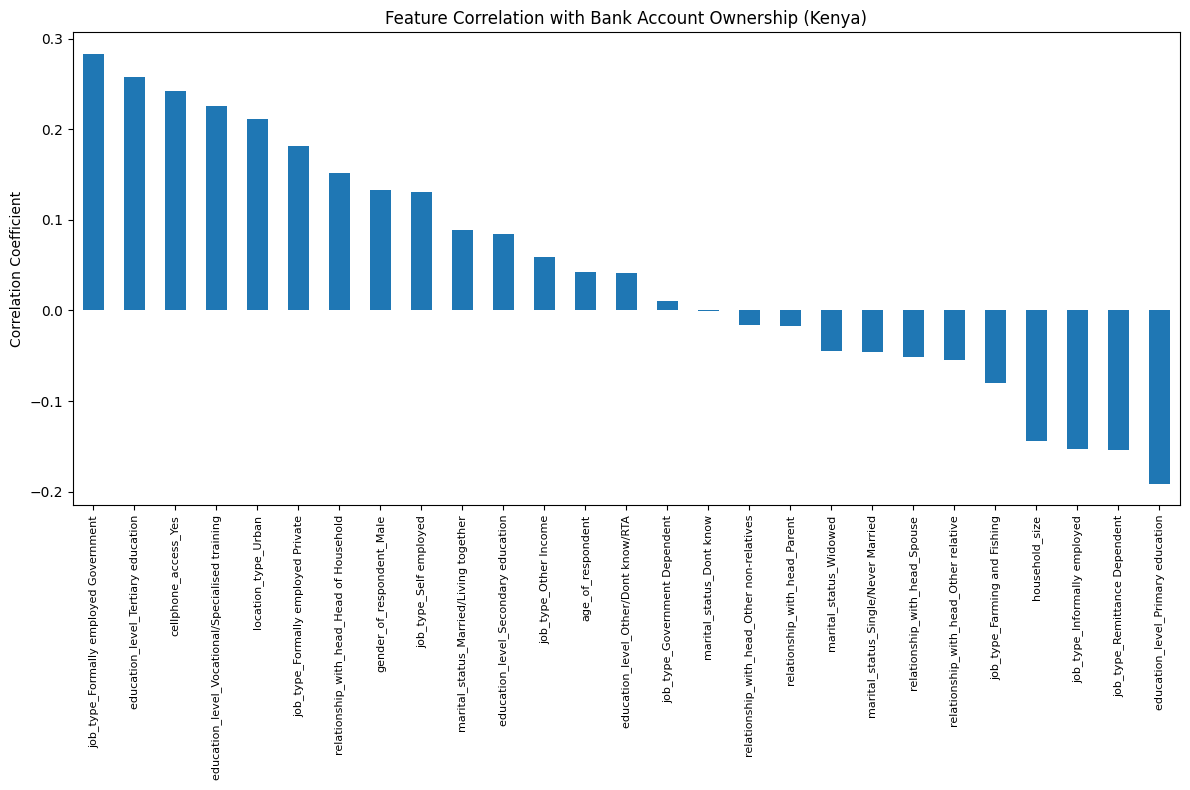

In [7]:
# 3. Exploration - Correlation with target
plt.figure(figsize=(12, 8))
corr = kenya_encoded.corr()['bank_account'].sort_values(ascending=False)
corr.drop('bank_account').plot(kind='bar')
plt.title('Feature Correlation with Bank Account Ownership (Kenya)')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('feature_correlation.png')

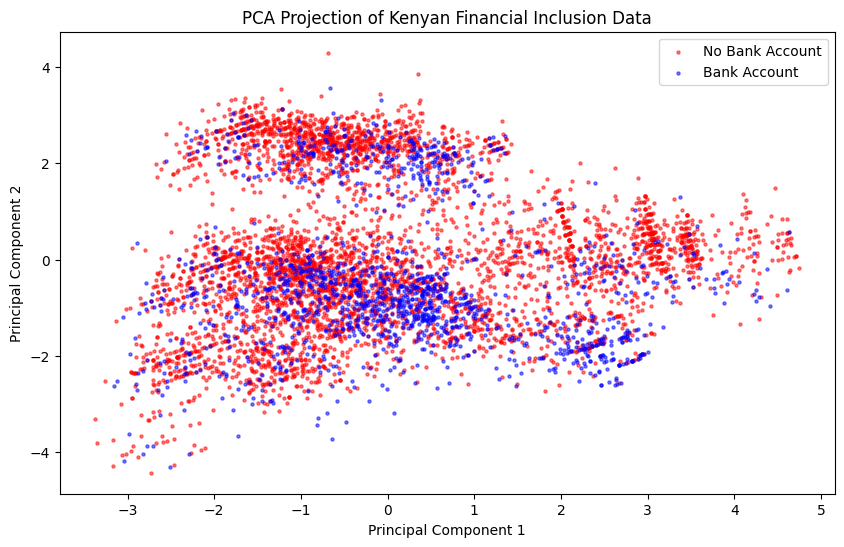

In [8]:
# 4. Dimension Reduction (PCA)
X = kenya_encoded.drop('bank_account', axis=1)
y = kenya_encoded['bank_account']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.5, label='No Bank Account', c='red', s=5)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.5, label='Bank Account', c='blue', s=5)
plt.title('PCA Projection of Kenyan Financial Inclusion Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_projection.png')

              precision    recall  f1-score   support

           0       0.80      0.87      0.84      1340
           1       0.53      0.40      0.46       481

    accuracy                           0.75      1821
   macro avg       0.67      0.64      0.65      1821
weighted avg       0.73      0.75      0.74      1821

[[1172  168]
 [ 289  192]]


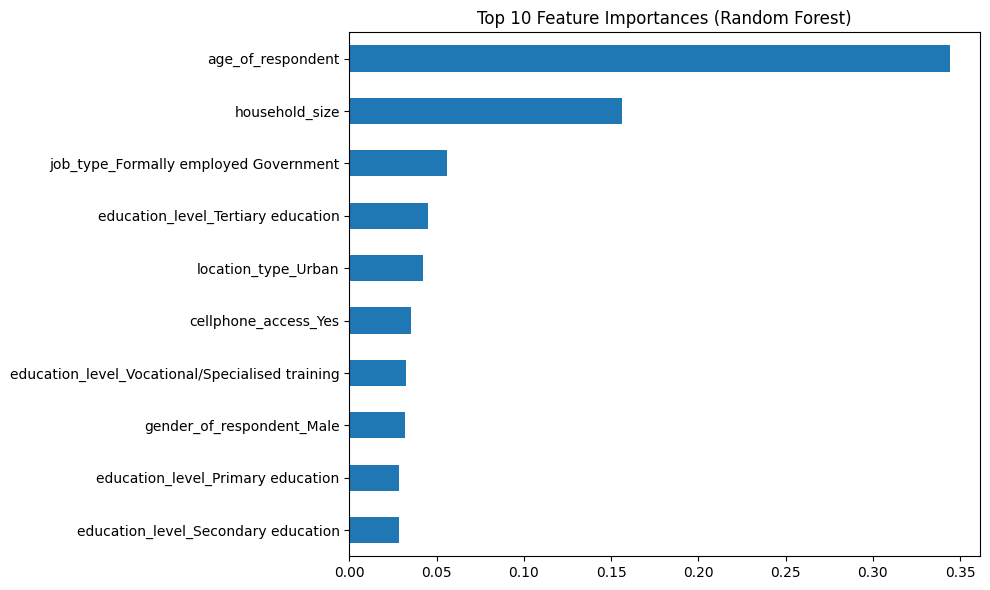

In [9]:
# 5. Algorithm Application (Classification - Random Forest)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(report)
print(conf_matrix)

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')